In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

In [2]:
%matplotlib inline

## Open crispresso batch summary file

In [3]:
mod_pct_summ_file = "../datasets/bcl11a/CRISPRessoBatch_on_1617.batch/Amplicon.MODIFICATION_PERCENTAGE_SUMMARY.txt"

In [4]:
mod_pct_summ = pd.read_csv(mod_pct_summ_file,sep="\t")
del_pct = mod_pct_summ[mod_pct_summ.Modification == "Deletions"]

val1 = del_pct.iloc[0,2:len(del_pct.columns)]
val1Name = del_pct.iloc[0,0]


val2 = del_pct.iloc[1,2:len(del_pct.columns)]
val2Name = del_pct.iloc[1,0]


### Log Fold Change Method

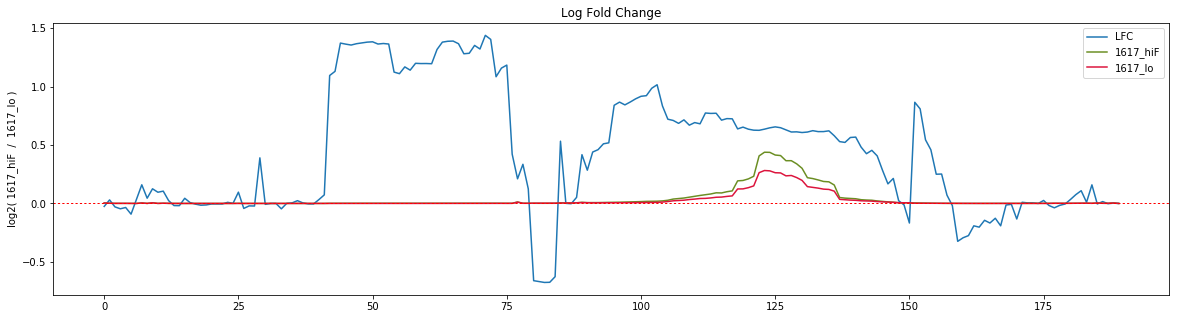

In [5]:
error = 0.001
per_base_vals_LFC = np.log2(((val1+error)/(val2+error)).astype(float)).replace(np.inf,0)

plt.figure(figsize = (20,5))
plt.plot(per_base_vals_LFC.values,label='LFC')
plt.plot(val1.values,color='olivedrab',label=val1Name)
plt.plot(val2.values,color='crimson',label=val2Name)
plt.axhline(linewidth=1, color='r',linestyle=":")
plt.ylabel("log2( " + val1Name + "  /  " + val2Name + " )")
plt.title('Log Fold Change')
plt.legend()

### Difference Method

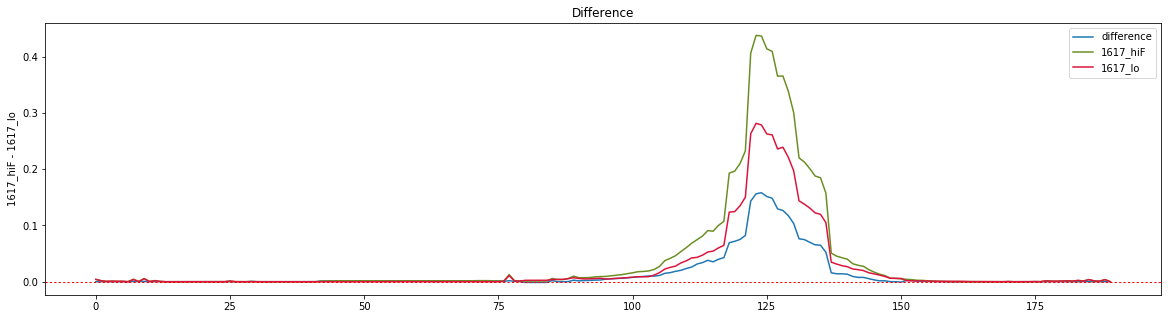

In [6]:
per_base_vals_diff = (val1-val2).astype(float).replace(np.inf,0)

plt.figure(figsize = (20,5))
plt.plot(per_base_vals_diff.values,label='difference')
plt.plot(val1.values,color='olivedrab',label=val1Name)
plt.plot(val2.values,color='crimson',label=val2Name)
plt.axhline(linewidth=1, color='r',linestyle=":")
plt.ylabel(val1Name + " - " + val2Name)
plt.title('Difference')
plt.legend()

## Weighting by alleles

In [7]:
file1 = "../datasets/bcl11a/CRISPRessoBatch_on_1617.batch/CRISPResso_on_1617_hiF/Alleles_frequency_table.txt"
name1 = "hiF"
file2 = "../datasets/bcl11a/CRISPRessoBatch_on_1617.batch/CRISPResso_on_1617_lo/Alleles_frequency_table.txt"
name2 = "lo"

data1 = pd.read_csv(file1,sep="\t")
data2 = pd.read_csv(file2,sep="\t")
data = pd.merge(data1,data2,on=['Aligned_Sequence','Reference_Sequence'],suffixes=["_"+name1,"_"+name2],how='outer')

data.replace(np.NaN,0)

def getDeletionIdxs(row):
    """
    Returns 0-based index of deletions for each row
    Deletion locations are those in which the Aligned_Sequence is "-" and Reference_Sequence is not "-"
    """
    delIdxs = []
    refIdx = 0 #the index in the reference sequence (increments except when ref_seq is "-")
    for idx in range(len(row['Aligned_Sequence'])):
        if (row['Aligned_Sequence'][idx] == row['Reference_Sequence']):
            refIdx += 1
        elif row['Aligned_Sequence'][idx] == "-":
            delIdxs.append(refIdx)
            refIdx += 1
        elif row['Reference_Sequence'][idx] == "-":
            pass
        else: #mismatch
            refIdx += 1
    return delIdxs

#test = {'Aligned_Sequence': "AAC--TG",
#       "Reference_Sequence":"A-CCTGG"}
#getDeletionIdxs(test)
            
#TAKES A LONG TIME
data['deletion_inds'] = data.apply(getDeletionIdxs,axis=1)

#Find length of reference
unmods = data.loc[data['Read_Status_hiF'] == 'UNMODIFIED','Reference_Sequence']
ref_len = len(unmods.iloc[1])

### LFC Allele contributions

In [8]:
#LFC
error = 0.001
data['each_LFC'] = np.log2(((data['%Reads_hiF']+error)/(data['%Reads_lo']+error)).astype(float)).replace([np.inf,np.NaN],0)

LFCcontributions = np.zeros(ref_len)

for index, row in data.iterrows():
    LFCcontributions[row['deletion_inds']] += row['each_LFC']
    
LFCcontributions = LFCcontributions/max(LFCcontributions)
    

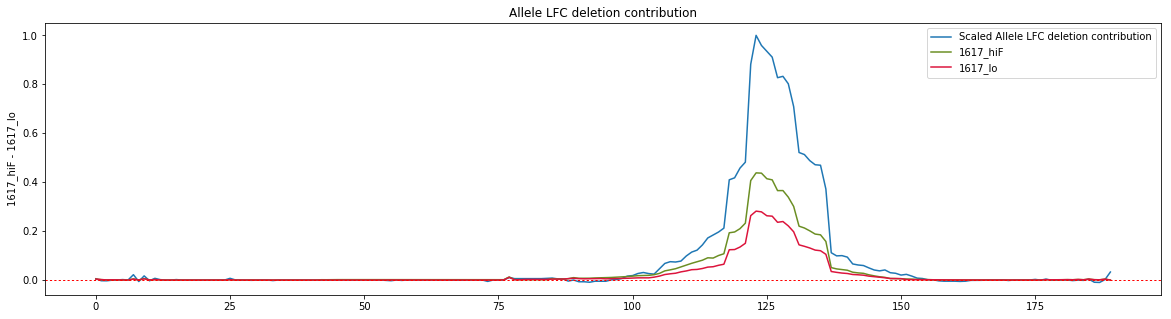

In [9]:
plt.figure(figsize = (20,5))
plt.plot(LFCcontributions,label='Scaled Allele LFC deletion contribution')
plt.plot(val1.values,color='olivedrab',label=val1Name)
plt.plot(val2.values,color='crimson',label=val2Name)
plt.axhline(linewidth=1, color='r',linestyle=":")
plt.ylabel(val1Name + " - " + val2Name)
plt.title('Allele LFC deletion contribution')
plt.legend()

In [10]:
#Difference
error = 0.001
data['each_diff'] = (data['%Reads_hiF']-data['%Reads_lo']).replace([np.inf,np.NaN],0)

diffContributions = np.zeros(ref_len)

for index, row in data.iterrows():
    diffContributions[row['deletion_inds']] += row['each_diff']
    
diffContributions = diffContributions/max(diffContributions)
    

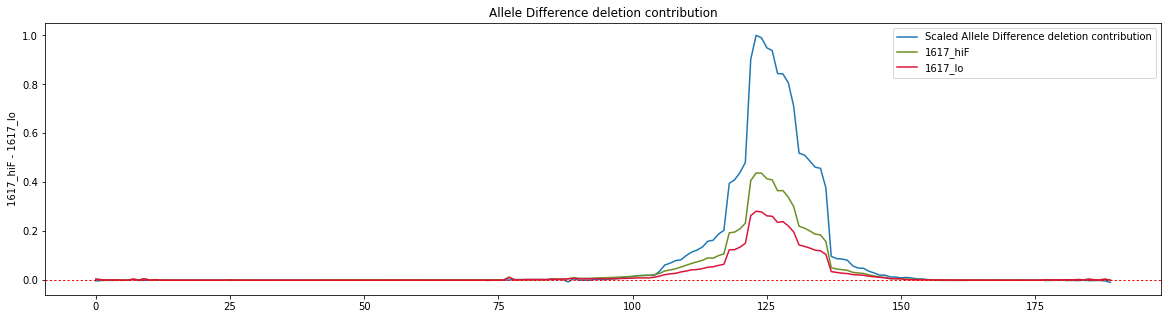

In [11]:
plt.figure(figsize = (20,5))
plt.plot(diffContributions,label='Scaled Allele Difference deletion contribution')
plt.plot(val1.values,color='olivedrab',label=val1Name)
plt.plot(val2.values,color='crimson',label=val2Name)
plt.axhline(linewidth=1, color='r',linestyle=":")
plt.ylabel(val1Name + " - " + val2Name)
plt.title('Allele Difference deletion contribution')
plt.legend()